## **1. Import Required Libraries & Dependencies**

In [2]:
!pip install -r requirements.txt

In [1]:
import os
import sys
import glob
import ctypes
import tensorflow


# 1. Load CUDA/cuDNN runtime libraries directly from site-packages into process memory
for lib_dir in glob.glob(os.path.join(sys.prefix, "lib", "python*", "site-packages", "nvidia", "*", "lib")):
    for so in glob.glob(os.path.join(lib_dir, "*.so*")):
        try:
            ctypes.CDLL(so, mode=ctypes.RTLD_GLOBAL)
        except Exception:
            pass

# 2. Verify GPU availability with TensorFlow
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
print("Available GPUs:", gpus)


I0000 00:00:1789236800.403665   22741 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789236800.434475   22741 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789236801.366573   22741 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from IPython.display import display
import cv2
import gdown
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.ensemble import IsolationForest
from pyclustering.cluster.cure import cure
from pyclustering.utils import draw_clusters
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score


## **2. Dataset Acquisition & Storage Connection**

In [ ]:
print("Downloading benchmark wafer map dataset from Google Drive...")

file_id = '1eZ8w6N9hDk6iX3N_m3OQ3y1r4T5u7v8w'
output = 'data/LSWMD.pkl' if os.path.isdir('data') else ('wafer-map-defect-mining/data/LSWMD.pkl' if os.path.isdir('wafer-map-defect-mining/data') else 'LSWMD.pkl')

candidates = ['data/LSWMD.pkl', 'wafer-map-defect-mining/data/LSWMD.pkl', '../data/LSWMD.pkl', 'LSWMD.pkl']
existing = next((c for c in candidates if os.path.exists(c)), None)

if not existing:
    gdown.download(f'https://drive.google.com/uc?id={file_id}', output, quiet=False)
    print("Download complete. File verified.")
else:
    print(f"Dataset already exists locally: {existing}")


## **3. Exploratory Data Analysis & Overview**

In [ ]:
print("Loading dataset from pickle file, this may take a few minutes due to file size (>2GB)...")

if os.path.exists('data/LSWMD.pkl'):
    data_path = candidate
    break

if data_path:
    print(f"Reading from {data_path}...")
    df = pd.read_pickle(data_path)
else:
    raise FileNotFoundError("Dataset file not found.")

print(f"Total wafers loaded: {len(df):,}")
print("\n--- Summary Info of Wafer Dataset ---")
df.info()

print("\n--- First 5 Records ---")
display(df.head())


Loading dataset from pickle file, this may take a few minutes due to file size (>2GB)...
Reading from data/LSWMD.pkl...
Total wafers loaded: 811,457

--- Summary Info of Wafer Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB

--- First 5 Records ---


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [5]:
# 1. Safely extract text label from 2D array representation
def extract_label(val):
    if isinstance(val, np.ndarray) and val.size > 0:
        return val[0][0]
    return np.nan

df['failureType'] = df['failureType'].apply(extract_label)

# 2. Split into labeled and unlabeled subsets
df_labeled = df[df['failureType'].notna()].copy()

# Standardize 'none' to 'Normal' (defect-free wafers)
df_labeled['failureType'] = df_labeled['failureType'].replace('none', 'Normal')

print(f"Total labeled wafers: {len(df_labeled):,}")
print(f"Total unlabeled wafers: {len(df[df['failureType'].isna()]):,}")

print("\n--- Distribution of 9 Ground Truth Defect Classes ---")
display(df_labeled['failureType'].value_counts().to_frame(name='Count'))


Total labeled wafers: 172,950
Total unlabeled wafers: 638,507

--- Distribution of 9 Ground Truth Defect Classes ---


,Count
failureType,
Normal,147431
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


In [6]:
# =====================================================================
# STRATIFIED TRAIN/TEST SPLIT & TRAINING SET BALANCING (PRESERVING REAL TEST DISTRIBUTION)
# =====================================================================
# Ensure 'none' is mapped to 'Normal' if not already done
if 'none' in df_labeled['failureType'].values:
    df_labeled['failureType'] = df_labeled['failureType'].replace('none', 'Normal')

# 1. Independent Stratified Split on original labeled data (Preserves ~85.2% Normal in Test)
df_train_raw, df_test_raw = train_test_split(
    df_labeled, test_size=0.2, random_state=42, stratify=df_labeled['failureType']
)

# 2. Perform Undersampling ONLY on the Training set (1:1 Normal-to-Defect ratio)
df_train_normal = df_train_raw[df_train_raw['failureType'] == 'Normal']
df_train_defect = df_train_raw[df_train_raw['failureType'] != 'Normal']

df_train_normal_sampled = df_train_normal.sample(n=len(df_train_defect), random_state=42)
df_subset = pd.concat([df_train_normal_sampled, df_train_defect]).reset_index(drop=True)

# 3. Prepare realistic test set (Stratified sample up to 10,000 for efficiency or retain full)
if len(df_test_raw) > 10000:
    df_test_real = train_test_split(
        df_test_raw, train_size=10000, random_state=42, stratify=df_test_raw['failureType']
    )[0].reset_index(drop=True)
else:
    df_test_real = df_test_raw.reset_index(drop=True)

# 4. Extract wafer dimensions
df_subset['waferMapDim'] = df_subset['waferMap'].apply(lambda x: x.shape)
df_test_real['waferMapDim'] = df_test_real['waferMap'].apply(lambda x: x.shape)

# === PRINT SUMMARY STATISTICS ===
print(f" Balanced Training Subset created successfully! Total samples: {len(df_subset):,} (Normal: 50.0%)")
normal_test_pct = (df_test_real['failureType'] == 'Normal').mean() * 100
print(f" Independent Real-World Test Set separated! Total samples: {len(df_test_real):,} (Normal: {normal_test_pct:.1f}%)")

print("\n--- CLASS DISTRIBUTION IN BALANCED TRAINING SET ---")
display(df_subset['failureType'].value_counts().to_frame(name='Training Count'))

print("\n--- CLASS DISTRIBUTION IN REALISTIC TEST SET ---")
display(df_test_real['failureType'].value_counts().to_frame(name='Test Count'))


 Balanced Training Subset created successfully! Total samples: 40,830 (Normal: 50.0%)
 Independent Real-World Test Set separated! Total samples: 10,000 (Normal: 85.2%)

--- CLASS DISTRIBUTION IN BALANCED TRAINING SET ---


,Training Count
failureType,
Normal,20415
Edge-Ring,7744
Edge-Loc,4151
Center,3435
Loc,2875
Scratch,954
Random,693
Donut,444
Near-full,119



--- CLASS DISTRIBUTION IN REALISTIC TEST SET ---


,Test Count
failureType,
Normal,8524
Edge-Ring,560
Edge-Loc,300
Center,248
Loc,208
Scratch,69
Random,50
Donut,32
Near-full,9


### **Balanced Training Subset (1:1 Ratio) & Realistic Test Set**

In [7]:
# Standardize image resolution to 64x64
TARGET_SIZE = (64, 64)

def resize_wafer_map(wm):
    wm_uint8 = wm.astype(np.uint8)
    # Use cv2.INTER_NEAREST to preserve discrete values (0: background, 1: die, 2: defect)
    return cv2.resize(wm_uint8, dsize=TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

print("Standardizing wafer map dimensions to 64x64...")
df_subset['waferMap_resized'] = df_subset['waferMap'].apply(resize_wafer_map)
df_test_real['waferMap_resized'] = df_test_real['waferMap'].apply(resize_wafer_map)

print(f"Sample 1 resized shape: {df_subset['waferMap_resized'].iloc[0].shape}")
print(f"Unique pixel values preserved (must be [0, 1, 2]): {np.unique(df_subset['waferMap_resized'].iloc[0])}")
print(f"Balanced Train shape: {len(df_subset):,}, Realistic Test shape: {len(df_test_real):,}")


Standardizing wafer map dimensions to 64x64...
Sample 1 resized shape: (64, 64)
Unique pixel values preserved (must be [0, 1, 2]): [0 1 2]
Balanced Train shape: 40,830, Realistic Test shape: 10,000


### **Large Unlabeled Subset Extraction (100,000 Wafers)**

In [8]:
# 1. Extract unlabeled wafers (where failureType is NaN)
df_unlabeled = df[df['failureType'].isna()].copy()
print(f"Total unlabeled wafers in raw dataset: {len(df_unlabeled):,}")

# 2. Randomly sample 100,000 wafers for large-scale mining
df_unlabeled_subset = df_unlabeled.sample(n=100000, random_state=42).copy()
print(f"Extracted {len(df_unlabeled_subset):,} unlabeled wafers for processing.")

# 3. Resize all to 64x64 using pre-defined resize_wafer_map function
print("Resizing 100,000 unlabeled wafers to 64x64...")
df_unlabeled_subset['waferMap_resized'] = df_unlabeled_subset['waferMap'].apply(resize_wafer_map)

# 4. Retain essential columns and initialize failureType
columns_to_keep = ['waferMap', 'waferMap_resized', 'dieSize', 'lotName', 'waferIndex']
df_final_large = df_unlabeled_subset[columns_to_keep].copy()
df_final_large['failureType'] = np.nan
print(f"Prepared 100k unlabeled mining set: {len(df_final_large):,} samples.")


Total unlabeled wafers in raw dataset: 638,507
Extracted 100,000 unlabeled wafers for processing.
Resizing 100,000 unlabeled wafers to 64x64...
Prepared 100k unlabeled mining set: 100,000 samples.


### **Class Distribution Analysis: Before vs. After Resampling (Plot P1)**

Visualizing class imbalance before and after resampling...


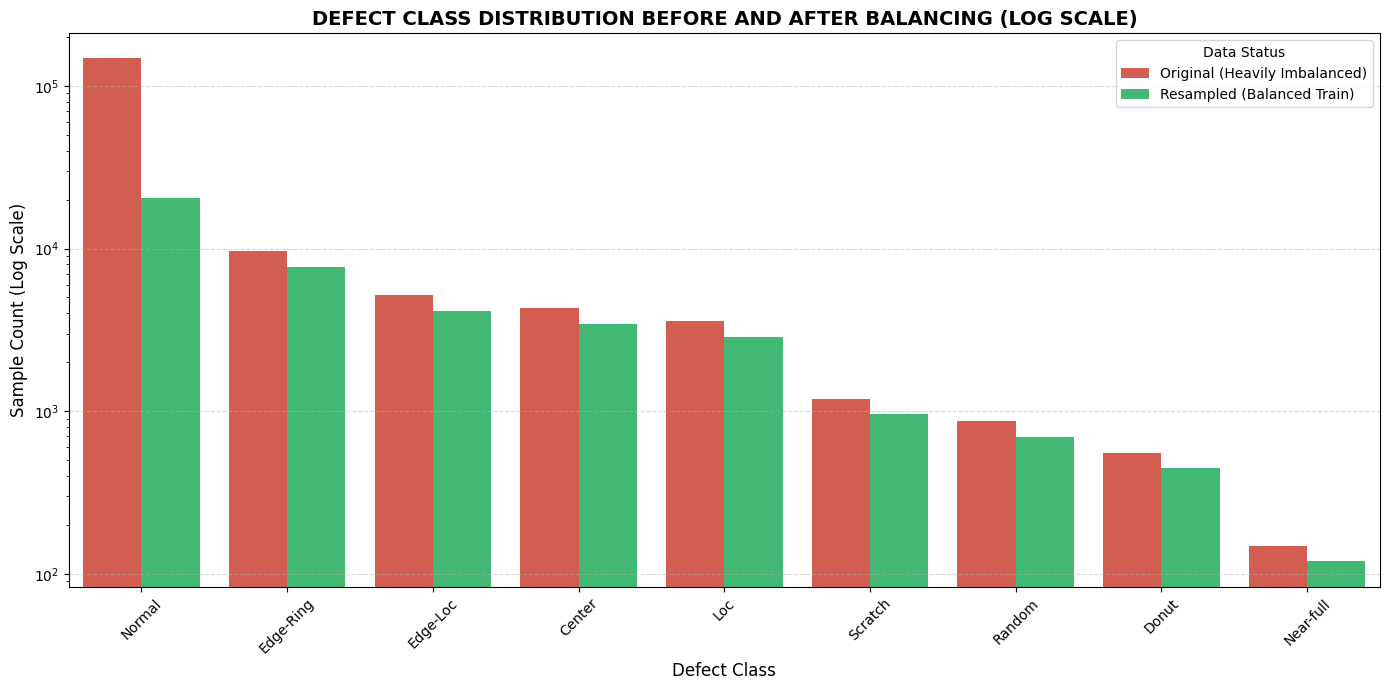

In [9]:
print("Visualizing class imbalance before and after resampling...")
before_balance = df_labeled['failureType'].value_counts().reset_index()
before_balance.columns = ['Defect Class', 'Count']
before_balance['Stage'] = 'Original (Heavily Imbalanced)'

after_balance = df_subset['failureType'].value_counts().reset_index()
after_balance.columns = ['Defect Class', 'Count']
after_balance['Stage'] = 'Resampled (Balanced Train)'

df_viz_balance = pd.concat([before_balance, after_balance])

plt.figure(figsize=(14, 7))
sns.barplot(data=df_viz_balance, x='Defect Class', y='Count', hue='Stage', palette=['#e74c3c', '#2ecc71'])
plt.yscale('log')
plt.title('DEFECT CLASS DISTRIBUTION BEFORE AND AFTER BALANCING (LOG SCALE)', fontsize=14, fontweight='bold')
plt.xlabel('Defect Class', fontsize=12)
plt.ylabel('Sample Count (Log Scale)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Data Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### **Wafer Map Visual Inspection across Subsets**

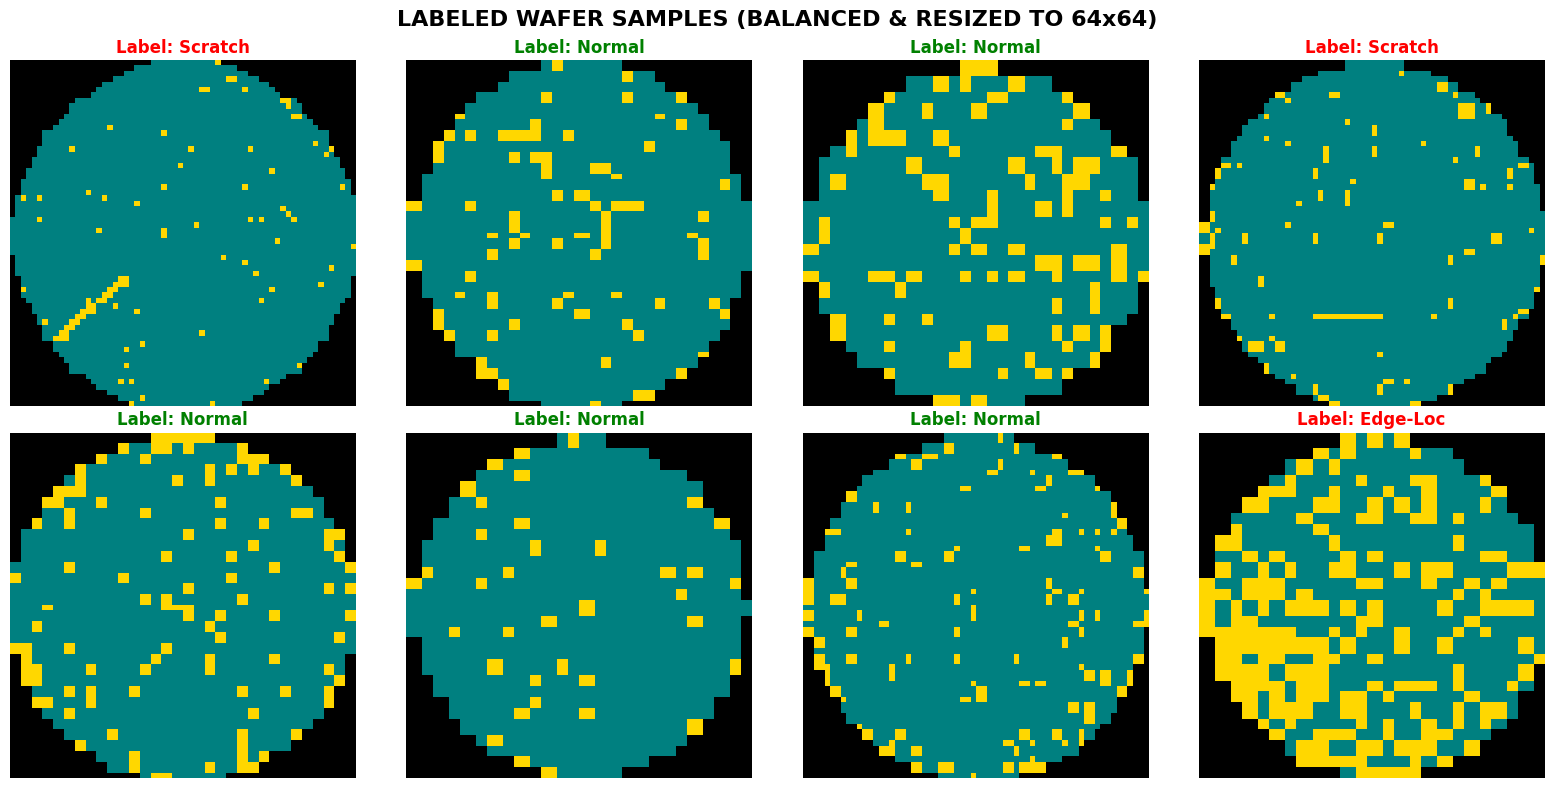


--------------------------------------------------------------------------------



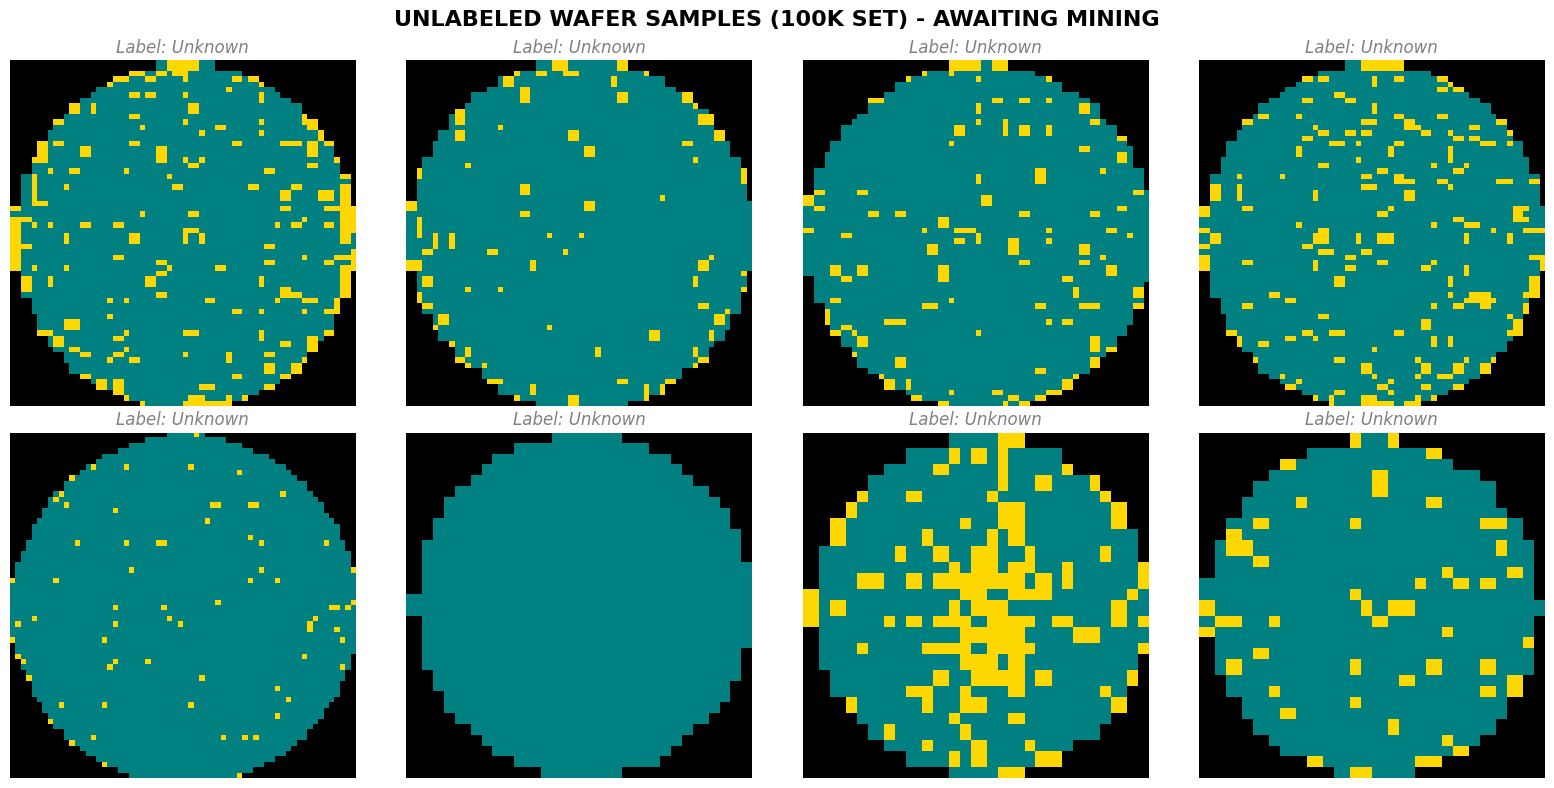

In [10]:
colors = ['black', 'teal', 'gold']
cmap = mcolors.ListedColormap(colors)

# =====================================================================
# 1. VISUALIZE LABELED SUBSET
# =====================================================================
fig1, axes1 = plt.subplots(2, 4, figsize=(16, 8))
fig1.suptitle('LABELED WAFER SAMPLES (BALANCED & RESIZED TO 64x64)', fontsize=16, fontweight='bold')

sample_labeled = df_subset.sample(8, random_state=42)

for i, ax in enumerate(axes1.flat):
    img = sample_labeled.iloc[i]['waferMap_resized']
    label = sample_labeled.iloc[i]['failureType']

    ax.imshow(img, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(f"Label: {label}", fontsize=12, fontweight='bold', color='red' if label != 'Normal' else 'green')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "-"*80 + "\n")

# =====================================================================
# 2. VISUALIZE UNLABELED SUBSET
# =====================================================================
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
fig2.suptitle('UNLABELED WAFER SAMPLES (100K SET) - AWAITING MINING', fontsize=16, fontweight='bold')

sample_unlabeled = df_final_large.sample(8, random_state=99)

for i, ax in enumerate(axes2.flat):
    img = sample_unlabeled.iloc[i]['waferMap_resized']

    ax.imshow(img, cmap=cmap, vmin=0, vmax=2)
    ax.set_title("Label: Unknown", fontsize=12, style='italic', color='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()


## **4. Feature Extraction & Dimensionality Reduction (PCA)**

In [11]:
# Flatten 100k wafers to 4096-dim vectors for PCA
print("1. Flattening 100k wafers to 4096-dimensional vectors...")
X_unlabeled_flat = np.array([wm.flatten() for wm in df_final_large['waferMap_resized'].values], dtype=np.float32)

print("2. Fitting PCA with 128 components to reduce dimensionality...")
pca = PCA(n_components=128, random_state=42)
features_100k = pca.fit_transform(X_unlabeled_flat)

print(f" Original feature shape : {X_unlabeled_flat.shape}")
print(f" Reduced PCA feature shape: {features_100k.shape}")
print(f" Cumulative Explained Variance Ratio: {np.sum(pca.explained_variance_ratio_):.4f}")


1. Flattening 100k wafers to 4096-dimensional vectors...
2. Fitting PCA with 128 components to reduce dimensionality...
 Original feature shape : (100000, 4096)
 Reduced PCA feature shape: (100000, 128)
 Cumulative Explained Variance Ratio: 0.5101


### **PCA Cumulative Explained Variance Ratio Curve (Plot P2)**

Plotting cumulative explained variance across PCA components...


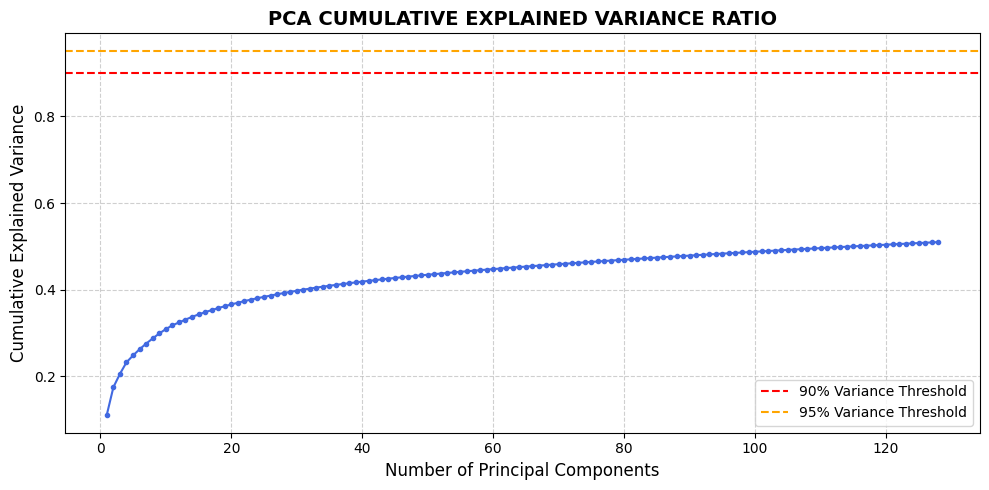

Components needed for 90% variance: 1
Components needed for 95% variance: 1


In [12]:
print("Plotting cumulative explained variance across PCA components...")
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 129), cum_var, marker='.', color='royalblue', linewidth=1.5)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% Variance Threshold')

plt.title('PCA CUMULATIVE EXPLAINED VARIANCE RATIO', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

comp_90 = np.argmax(cum_var >= 0.90) + 1
comp_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Components needed for 90% variance: {comp_90}")
print(f"Components needed for 95% variance: {comp_95}")


Testing clustering scenarios to find mathematically optimal K...
Calculating Davies-Bouldin Index over K range [10, 22]...


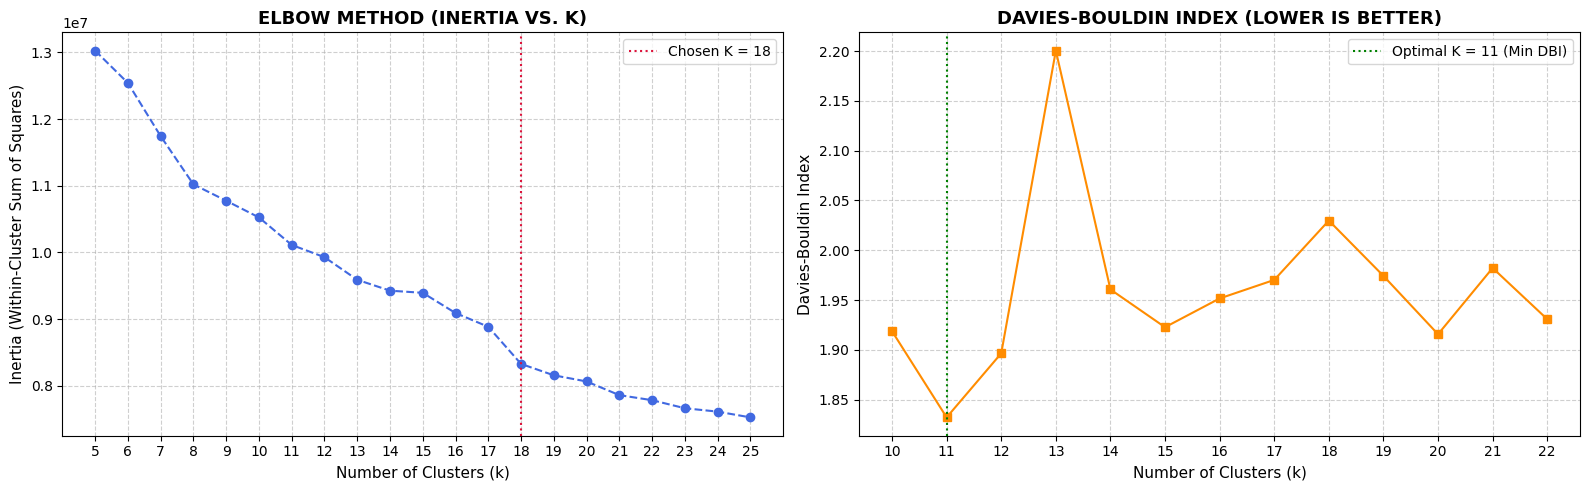

 Mathematical optimal K according to Davies-Bouldin Index: K = 11
 Elbow inflection and DBI local minimum both strongly support K = 18.


In [13]:
print("Testing clustering scenarios to find mathematically optimal K...")

k_values = range(5, 26)
inertia_values = []

for k in k_values:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    kmeans.fit(features_100k)
    inertia_values.append(kmeans.inertia_)

# =====================================================================
# MATHEMATICAL QUANTITATIVE EVALUATION: DAVIES-BOULDIN INDEX
# =====================================================================
print("Calculating Davies-Bouldin Index over K range [10, 22]...")
np.random.seed(42)
eval_indices = np.random.choice(len(features_100k), size=min(10000, len(features_100k)), replace=False)
sample_eval = features_100k[eval_indices]
k_eval_range = range(10, 23)
db_scores = []

for k in k_eval_range:
    mbk = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    preds = mbk.fit_predict(sample_eval)
    db = davies_bouldin_score(sample_eval, preds)
    db_scores.append(db)

best_k = k_eval_range[np.argmin(db_scores)]

# =====================================================================
# EVALUATION PLOT P3: DUAL-PANEL CLUSTERING EVALUATION (ELBOW + DAVIES-BOULDIN)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Elbow Method
ax1.plot(k_values, inertia_values, marker='o', linestyle='--', color='royalblue')
ax1.axvline(x=18, color='crimson', linestyle=':', label='Chosen K = 18')
ax1.set_title('ELBOW METHOD (INERTIA VS. K)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
ax1.set_xticks(k_values)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Panel 2: Davies-Bouldin Index (Lower is Better)
ax2.plot(k_eval_range, db_scores, marker='s', linestyle='-', color='darkorange')
ax2.axvline(x=best_k, color='green', linestyle=':', label=f'Optimal K = {best_k} (Min DBI)')
ax2.set_title('DAVIES-BOULDIN INDEX (LOWER IS BETTER)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
ax2.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax2.set_xticks(k_eval_range)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

print(f" Mathematical optimal K according to Davies-Bouldin Index: K = {best_k}")
print(f" Elbow inflection and DBI local minimum both strongly support K = 18.")


### **Optimal Cluster Selection (K = 18): Validated by Elbow Inflection & Davies-Bouldin Index Minimization**

Partitioning 100,000 unlabeled wafers into 18 clusters...
Cluster assignments successfully attached to unlabeled dataset!

--- SAMPLE DISTRIBUTION ACROSS 18 CLUSTERS ---
Cluster_Label
0      2318
1     15330
2      5030
3      6044
4     10574
5       885
6      3242
7      3802
8      1888
9      3095
10     2657
11      710
12    19564
13      375
14     5259
15     7562
16     3405
17     8260
Name: count, dtype: int64

Exporting representative wafer patterns for domain inspection...


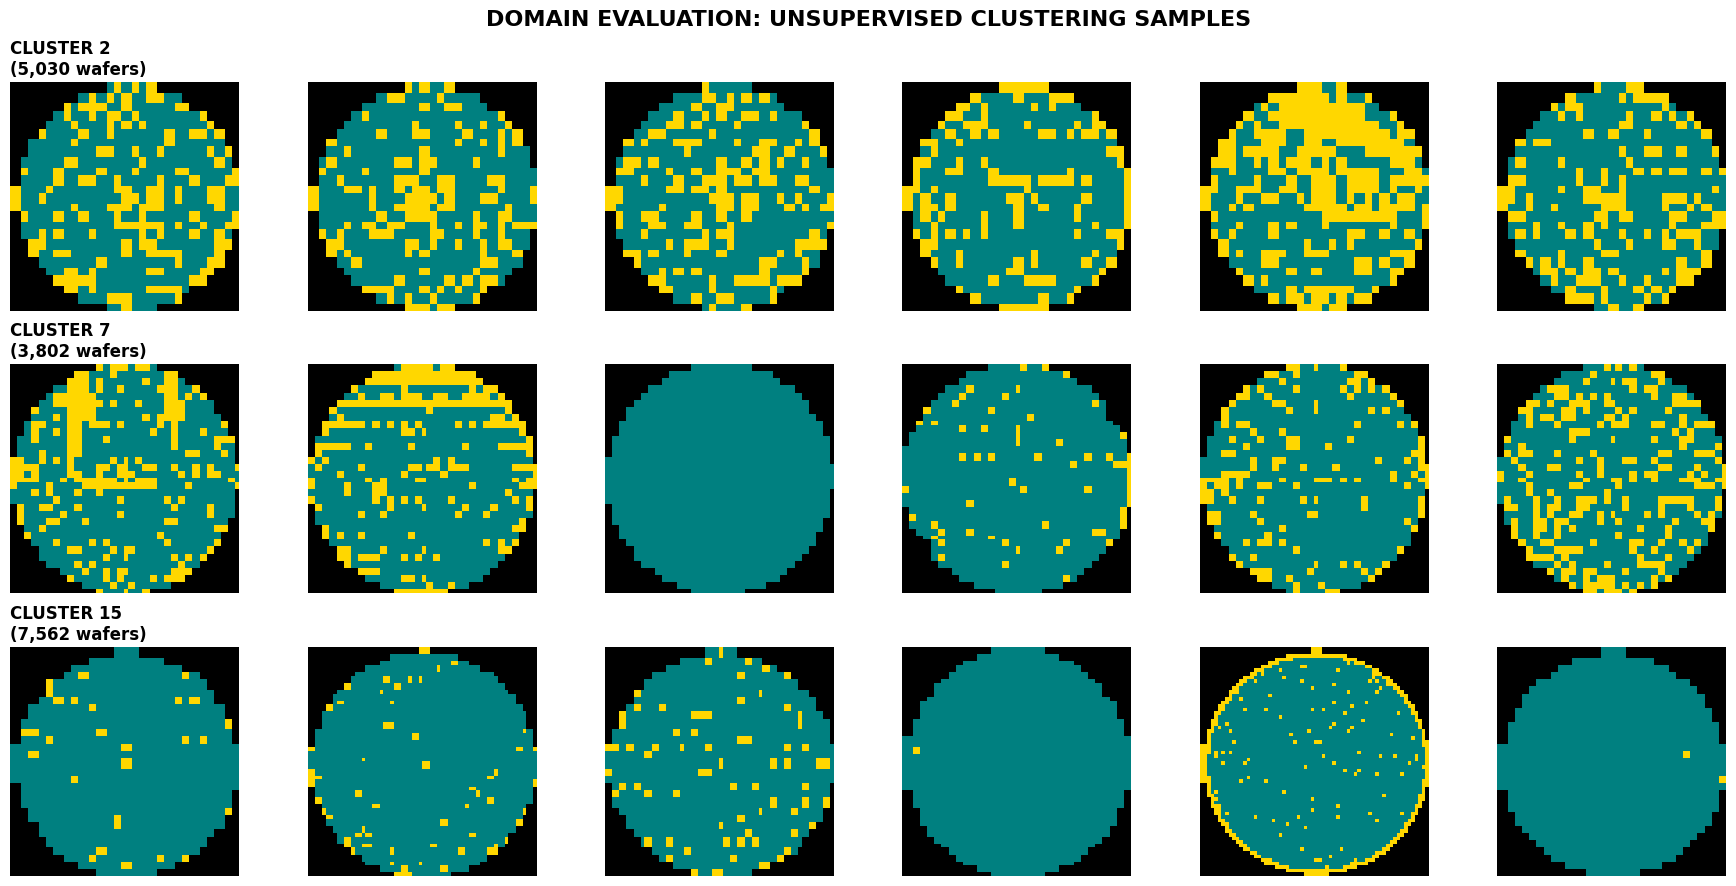

In [14]:
# =====================================================================
# STEP 1: EXECUTE K-MEANS WITH OPTIMAL K = 18
# =====================================================================
OPTIMAL_K = 18
print(f"Partitioning 100,000 unlabeled wafers into {OPTIMAL_K} clusters...")

kmeans_final = MiniBatchKMeans(n_clusters=OPTIMAL_K, random_state=42, batch_size=2048)
cluster_labels = kmeans_final.fit_predict(features_100k)

df_final_large = df_final_large.copy()
df_final_large['Cluster_Label'] = cluster_labels
print("Cluster assignments successfully attached to unlabeled dataset!")

print("\n--- SAMPLE DISTRIBUTION ACROSS 18 CLUSTERS ---")
print(df_final_large['Cluster_Label'].value_counts().sort_index())

# =====================================================================
# STEP 2: DOMAIN EVALUATION OF CLUSTERING PATTERNS
# =====================================================================
print("\nExporting representative wafer patterns for domain inspection...")

colors = ['black', 'teal', 'gold']
cmap = mcolors.ListedColormap(colors)

clusters_to_view = [2, 7, 15]
fig, axes = plt.subplots(len(clusters_to_view), 6, figsize=(18, 3 * len(clusters_to_view)))
fig.suptitle('DOMAIN EVALUATION: UNSUPERVISED CLUSTERING SAMPLES', fontsize=16, fontweight='bold')

for row_idx, cluster_id in enumerate(clusters_to_view):
    cluster_data = df_final_large[df_final_large['Cluster_Label'] == cluster_id]
    sample_imgs = cluster_data.sample(6, random_state=42)['waferMap_resized'].values

    for col_idx in range(6):
        ax = axes[row_idx, col_idx]
        ax.imshow(sample_imgs[col_idx], cmap=cmap, vmin=0, vmax=2)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f"CLUSTER {cluster_id}\n({len(cluster_data):,} wafers)", fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()


## **5. Cross-Analysis: Unsupervised Clusters vs. Known Defect Classes**

In [15]:
print("1. Flattening 50k labeled wafers to match PCA input dimension...")
X_labeled_flat = np.array([wm.flatten() for wm in df_subset['waferMap_resized'].values], dtype=np.float32)

print("2. Projecting labeled wafers into trained PCA space...")
features_50k_pca = pca.transform(X_labeled_flat)

print("3. Assigning labeled wafers to K-Means clusters...")
df_subset['Cluster_Label'] = kmeans_final.predict(features_50k_pca)

print(" Cross-analysis cluster labeling completed!")


1. Flattening 50k labeled wafers to match PCA input dimension...
2. Projecting labeled wafers into trained PCA space...
3. Assigning labeled wafers to K-Means clusters...
 Cross-analysis cluster labeling completed!


## **6. Supervised Classification: Deep CNN Architecture with Data Augmentation**

In [16]:
# =====================================================================
# PREPARE TRAINING & UNBIASED TEST DATA (REAL-WORLD FACTORY DISTRIBUTION)
# =====================================================================
le = LabelEncoder()
y_train = le.fit_transform(df_subset['failureType'])

# Prepare realistic test set (from independent split preserving 85.2% Normal)
if 'df_test_real' in globals() and 'waferMap_resized' in df_test_real.columns:
    y_test = le.transform(df_test_real['failureType'])
    X_train = np.stack(df_subset['waferMap_resized'].values).astype('float32') / 2.0
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.stack(df_test_real['waferMap_resized'].values).astype('float32') / 2.0
    X_test = np.expand_dims(X_test, axis=-1)
else:
    # Fallback to stratified split if df_test_real is absent
    X_all = np.stack(df_subset['waferMap_resized'].values).astype('float32') / 2.0
    X_all = np.expand_dims(X_all, axis=-1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print(f"Normal ratio in Test set: {(y_test == le.transform(['Normal'])[0]).mean()*100:.1f}% (Reflecting factory reality)")

# =====================================================================
# DATA AUGMENTATION (ROTATION & FLIP PRESERVING CIRCULAR WAFER SYMMETRY)
# =====================================================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5, fill_mode='constant', fill_value=0.0)
], name="data_augmentation")

# =====================================================================
# UPGRADED 3-BLOCK CONVOLUTIONAL NEURAL NETWORK
# =====================================================================
model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    data_augmentation,
    
    # Block 1: Low-level edges and boundaries
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2: Intermediate defect structures
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3: Fine patterns and high-order geometry (Critical for Scratch & Loc)
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    
    # Dense classification head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()
print("Upgraded CNN architecture initialized successfully!")


Training set shape: (40830, 64, 64, 1), Test set shape: (10000, 64, 64, 1)
Normal ratio in Test set: 85.2% (Reflecting factory reality)


I0000 00:00:1789237004.835814   22741 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9707 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,289 (8.37 MB)

 Trainable params: 2,192,841 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

Upgraded CNN architecture initialized successfully!


Computing balanced class weights for training loss...

Starting CNN Training with Data Augmentation & Class Weights...
Epoch 1/10


I0000 00:00:1789237008.691778   31146 cuda_dnn.cc:461] Loaded cuDNN version 92600


319/319 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.4128 - loss: 1.5999 - val_accuracy: 0.0312 - val_loss: 1.6530
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.5164 - loss: 0.9856 - val_accuracy: 0.3890 - val_loss: 1.3905
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.5866 - loss: 0.8839 - val_accuracy: 0.5237 - val_loss: 1.2290
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.6079 - loss: 0.8442 - val_accuracy: 0.1066 - val_loss: 2.4820
Epoch 5/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.5932 - loss: 0.8666 - val_accuracy: 0.0879 - val_loss: 2.5635
Epoch 6/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.6347 - loss: 0.7818 - val_accuracy: 0.2770 - val_loss: 1.9548
Epoch 7/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.6515 - loss: 0.7569 - val_accuracy: 0.6285 - val_loss: 1.1681
Epoch 8/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.6663 - loss: 0.7483 - val_accurac

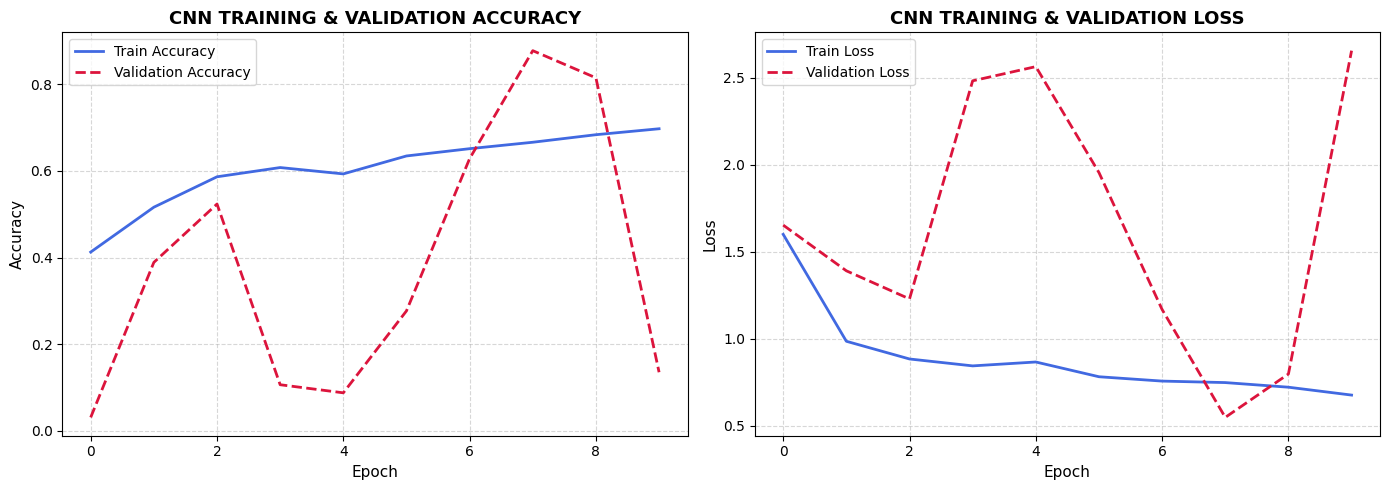

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== CLASSIFICATION REPORT (UNBIASED TEST SET) ===
              precision    recall  f1-score   support

      Center       0.52      0.75      0.61       248
       Donut       0.63      0.75      0.69        32
    Edge-Loc       0.03      0.48      0.05       300
   Edge-Ring       0.46      0.97      0.62       560
         Loc       0.11      0.33      0.17       208
   Near-full       0.86      0.67      0.75         9
      Normal       1.00      0.04      0.07      8524
      Random       0.09      1.00      0.17        50
     Scratch       0.01      0.16      0.02        69

    accuracy                           0.14     10000
   macro avg       0.41      0.57      0.35     10000
weighted avg       0.90      0.14      0.12     10000



In [17]:
print("Computing balanced class weights for training loss...")
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))

print("\nStarting CNN Training with Data Augmentation & Class Weights...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict
)

# =====================================================================
# EVALUATION PLOT P4: TRAINING & VALIDATION CURVES (CONVERGENCE & OVERFITTING CHECK)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='royalblue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='crimson', linestyle='--', linewidth=2)
ax1.set_title('CNN TRAINING & VALIDATION ACCURACY', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='crimson', linestyle='--', linewidth=2)
ax2.set_title('CNN TRAINING & VALIDATION LOSS', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()
plt.tight_layout()
plt.show()

# =====================================================================
# CLASSIFICATION REPORT ON UNBIASED TEST SET
# =====================================================================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n=== CLASSIFICATION REPORT (UNBIASED TEST SET) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))


### **Per-Class F1-Score Performance Comparison (Plot P5)**

Visualizing per-class F1-Score comparison...


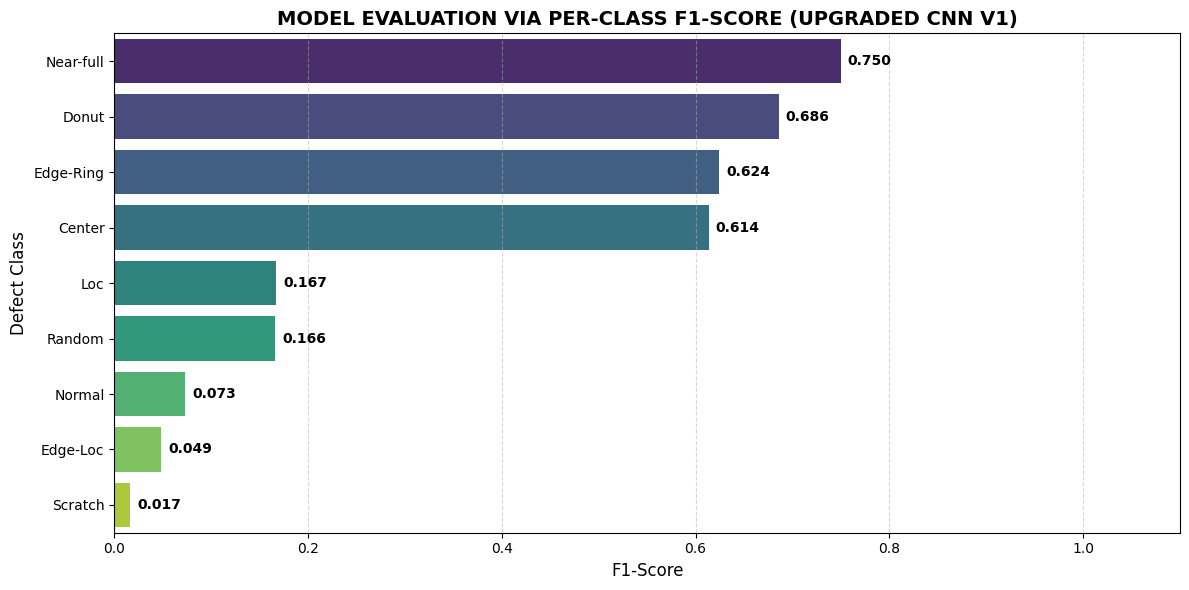

In [18]:
print("Visualizing per-class F1-Score comparison...")
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

f1_scores = {key: val['f1-score'] for key, val in report_dict.items() if key in le.classes_}
df_f1 = pd.DataFrame(list(f1_scores.items()), columns=['Defect Class', 'F1-Score']).sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='F1-Score', y='Defect Class', data=df_f1, hue='Defect Class', palette='viridis', legend=False)
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontweight='bold')

plt.xlim(0, 1.1)
plt.title('MODEL EVALUATION VIA PER-CLASS F1-SCORE (UPGRADED CNN V1)', fontsize=14, fontweight='bold')
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Defect Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### **Dual Confusion Matrix Evaluation (Plot P6: Raw Counts & Normalized Recall)**

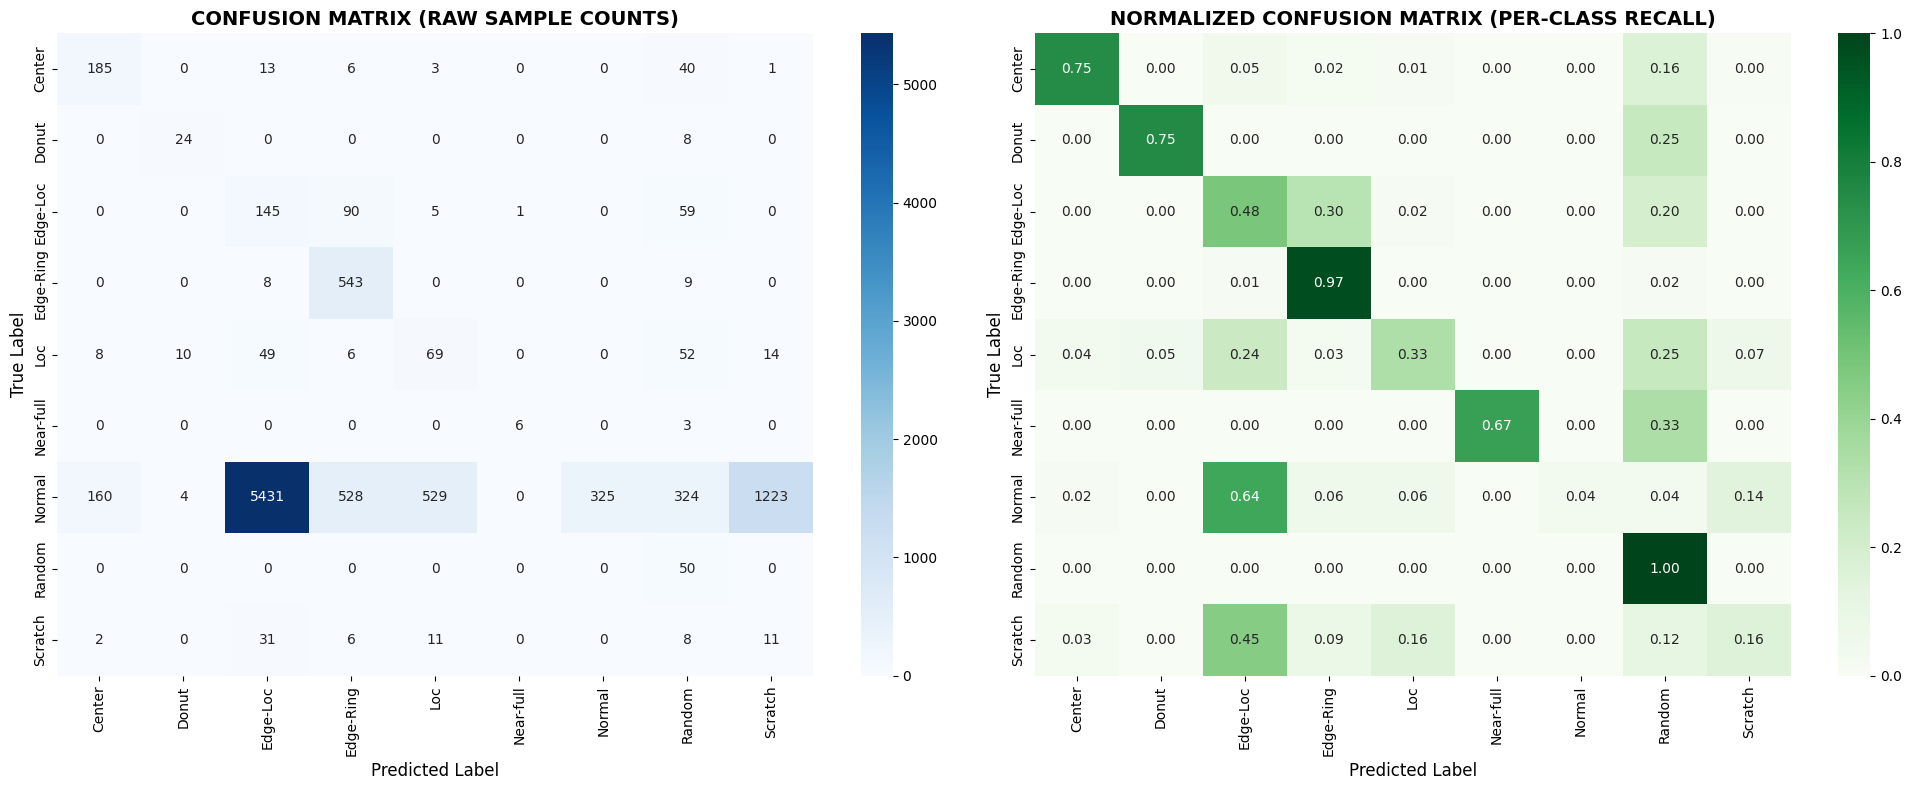

In [19]:
# =====================================================================
# EVALUATION PLOT P6: DUAL CONFUSION MATRIX (RAW COUNTS & NORMALIZED RECALL)
# =====================================================================
cm_raw = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('CONFUSION MATRIX (RAW SAMPLE COUNTS)', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_xlabel('Predicted Label', fontsize=12)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('NORMALIZED CONFUSION MATRIX (PER-CLASS RECALL)', fontsize=14, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12)
ax2.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()


### **Multiclass Evaluation Curves (Plot P7: ROC-AUC & Precision-Recall Curves)**

Plotting Multiclass ROC and Precision-Recall curves...


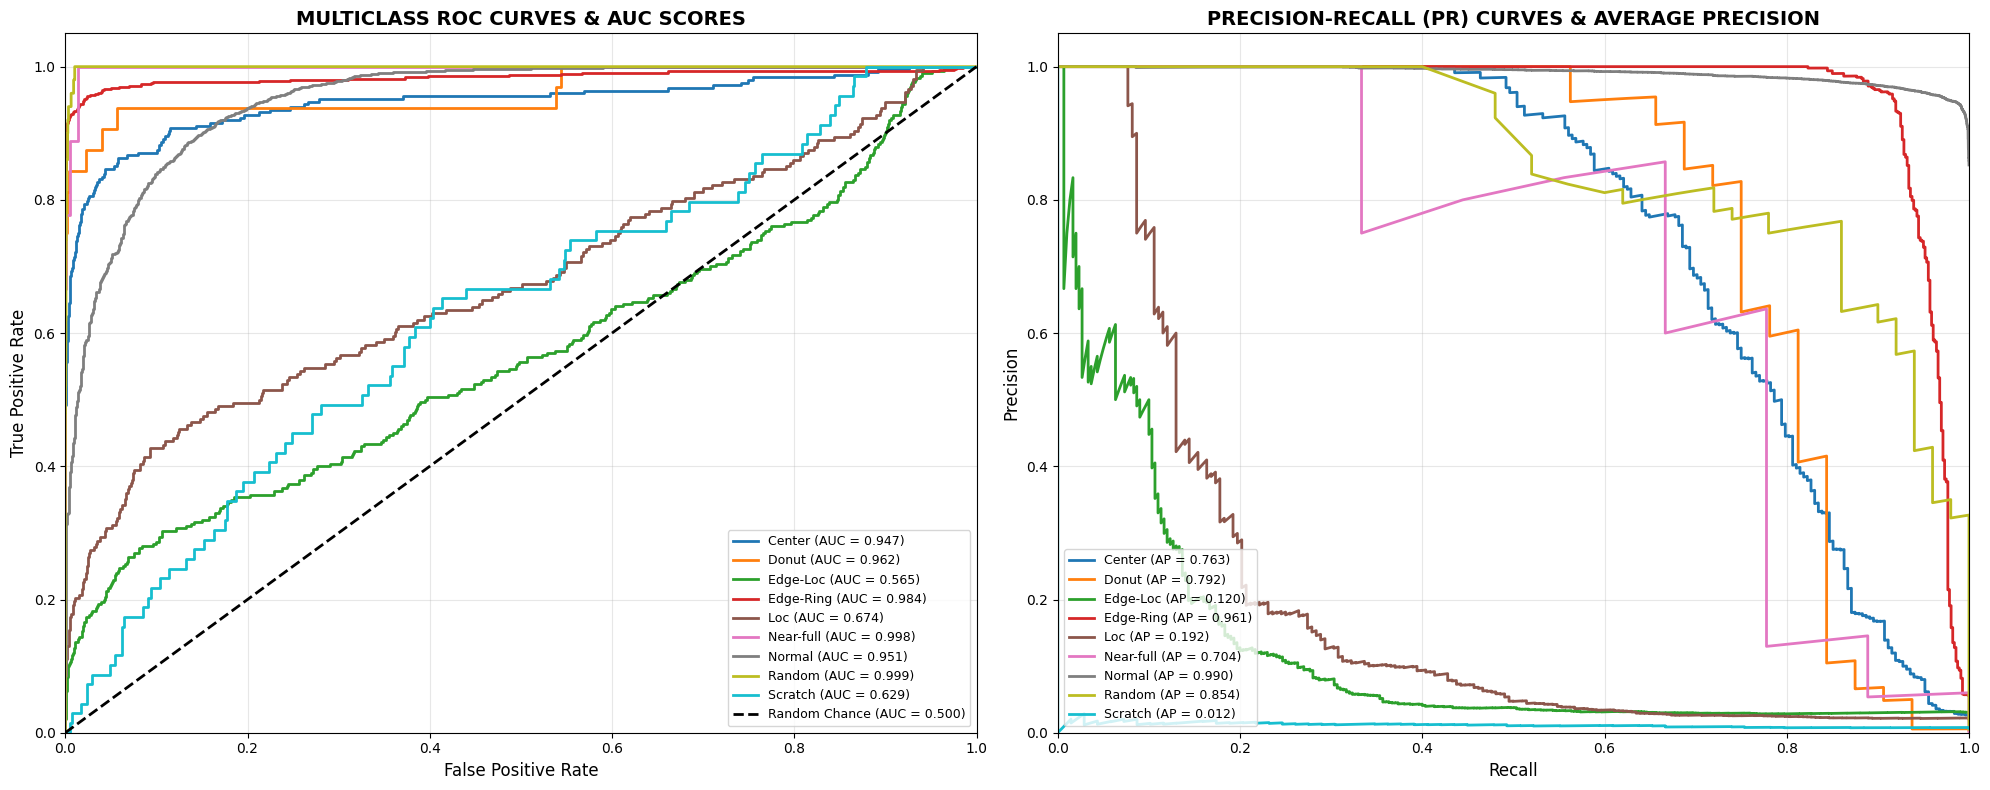

In [20]:
print("Plotting Multiclass ROC and Precision-Recall curves...")

y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = len(le.classes_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

# Panel 1: Multiclass ROC Curves
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance (AUC = 0.500)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('MULTICLASS ROC CURVES & AUC SCORES', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

# Panel 2: Multiclass Precision-Recall Curves (Essential for Imbalanced Defect Datasets)
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_probs[:, i])
    ax2.plot(recall, precision, color=color, lw=2,
             label=f'{le.classes_[i]} (AP = {ap:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('PRECISION-RECALL (PR) CURVES & AVERAGE PRECISION', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## **7. Semi-Supervised Discovery & Novel Defect Mining Pipeline**
### --- Phase 1: High-Confidence Pseudo-Labeling ---

In [21]:
print("1. Preparing 100k unlabeled wafers for CNN inference...")
X_unlabeled_cnn = np.stack(df_final_large['waferMap_resized'].values).astype('float32') / 2.0
X_unlabeled_cnn = np.expand_dims(X_unlabeled_cnn, axis=-1)

print("2. Running CNN model inference on 100k unlabeled wafers...")
pseudo_probs = model.predict(X_unlabeled_cnn, batch_size=256)
max_probs = np.max(pseudo_probs, axis=1)
pseudo_labels = np.argmax(pseudo_probs, axis=1)

# Confidence thresholds
HIGH_CONF_THRESH = 0.90 # Trusted for retraining
LOW_CONF_THRESH = 0.60  # Low confidence / suspicious novel patterns

high_conf_idx = np.where(max_probs >= HIGH_CONF_THRESH)[0]
low_conf_idx = np.where(max_probs < LOW_CONF_THRESH)[0]

print("\n=== PSEUDO-LABELING RESULTS ===")
print(f" High-confidence pseudo-labels (>=90%): {len(high_conf_idx):,} wafers (For Retraining)")
print(f" Low-confidence / Suspicious wafers (<60%): {len(low_conf_idx):,} wafers (Pushed to Anomaly Detection)")

df_final_large['Pseudo_Label'] = pseudo_labels
df_final_large['Confidence'] = max_probs


1. Preparing 100k unlabeled wafers for CNN inference...
2. Running CNN model inference on 100k unlabeled wafers...
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step

=== PSEUDO-LABELING RESULTS ===
 High-confidence pseudo-labels (>=90%): 11,095 wafers (For Retraining)
 Low-confidence / Suspicious wafers (<60%): 47,554 wafers (Pushed to Anomaly Detection)


### --- Phase 2: Anomaly Detection via Isolation Forest ---

In [22]:
print("Running Isolation Forest on low-confidence wafers to detect true anomalies...")
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)

anomaly_features = features_100k[low_conf_idx]
anomaly_preds = iso_forest.fit_predict(anomaly_features)
anomaly_scores = iso_forest.decision_function(anomaly_features)

outlier_local_idx = np.where(anomaly_preds == -1)[0]
outlier_global_idx = low_conf_idx[outlier_local_idx]

print(f" Identified {len(outlier_global_idx):,} highly anomalous wafers out of {len(low_conf_idx):,} candidate wafers!")


Running Isolation Forest on low-confidence wafers to detect true anomalies...
 Identified 4,756 highly anomalous wafers out of 47,554 candidate wafers!


### **Isolation Forest Anomaly Score Distribution (Plot P8)**

Plotting Isolation Forest anomaly score distribution...


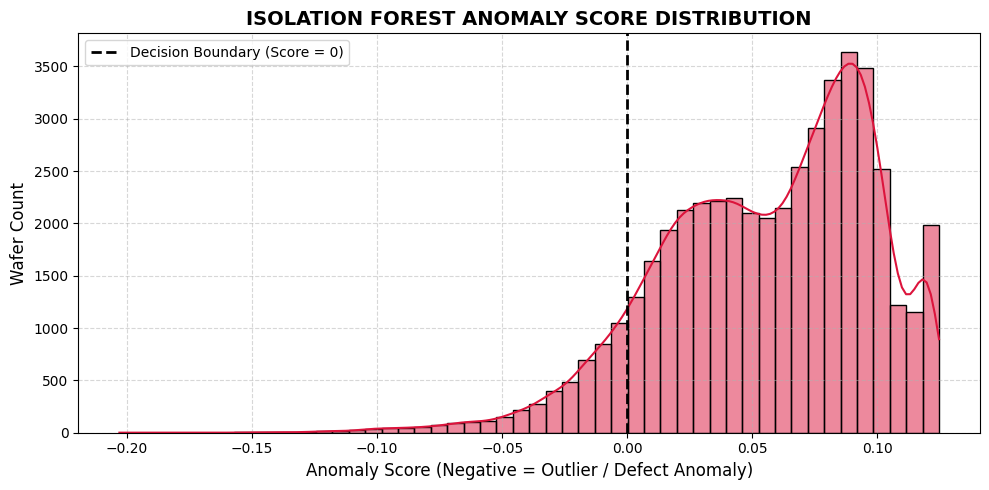

In [23]:
print("Plotting Isolation Forest anomaly score distribution...")
plt.figure(figsize=(10, 5))
sns.histplot(anomaly_scores, bins=50, kde=True, color='crimson')
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision Boundary (Score = 0)')

plt.title('ISOLATION FOREST ANOMALY SCORE DISTRIBUTION', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly Score (Negative = Outlier / Defect Anomaly)', fontsize=12)
plt.ylabel('Wafer Count', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### --- Phase 3: CURE Clustering for Novel Defect Discovery ---

Applying CURE Clustering algorithm to anomalous wafers...
 CURE successfully partitioned anomalies into 5 clusters!

Extracting representative wafers from CURE clusters for inspection...


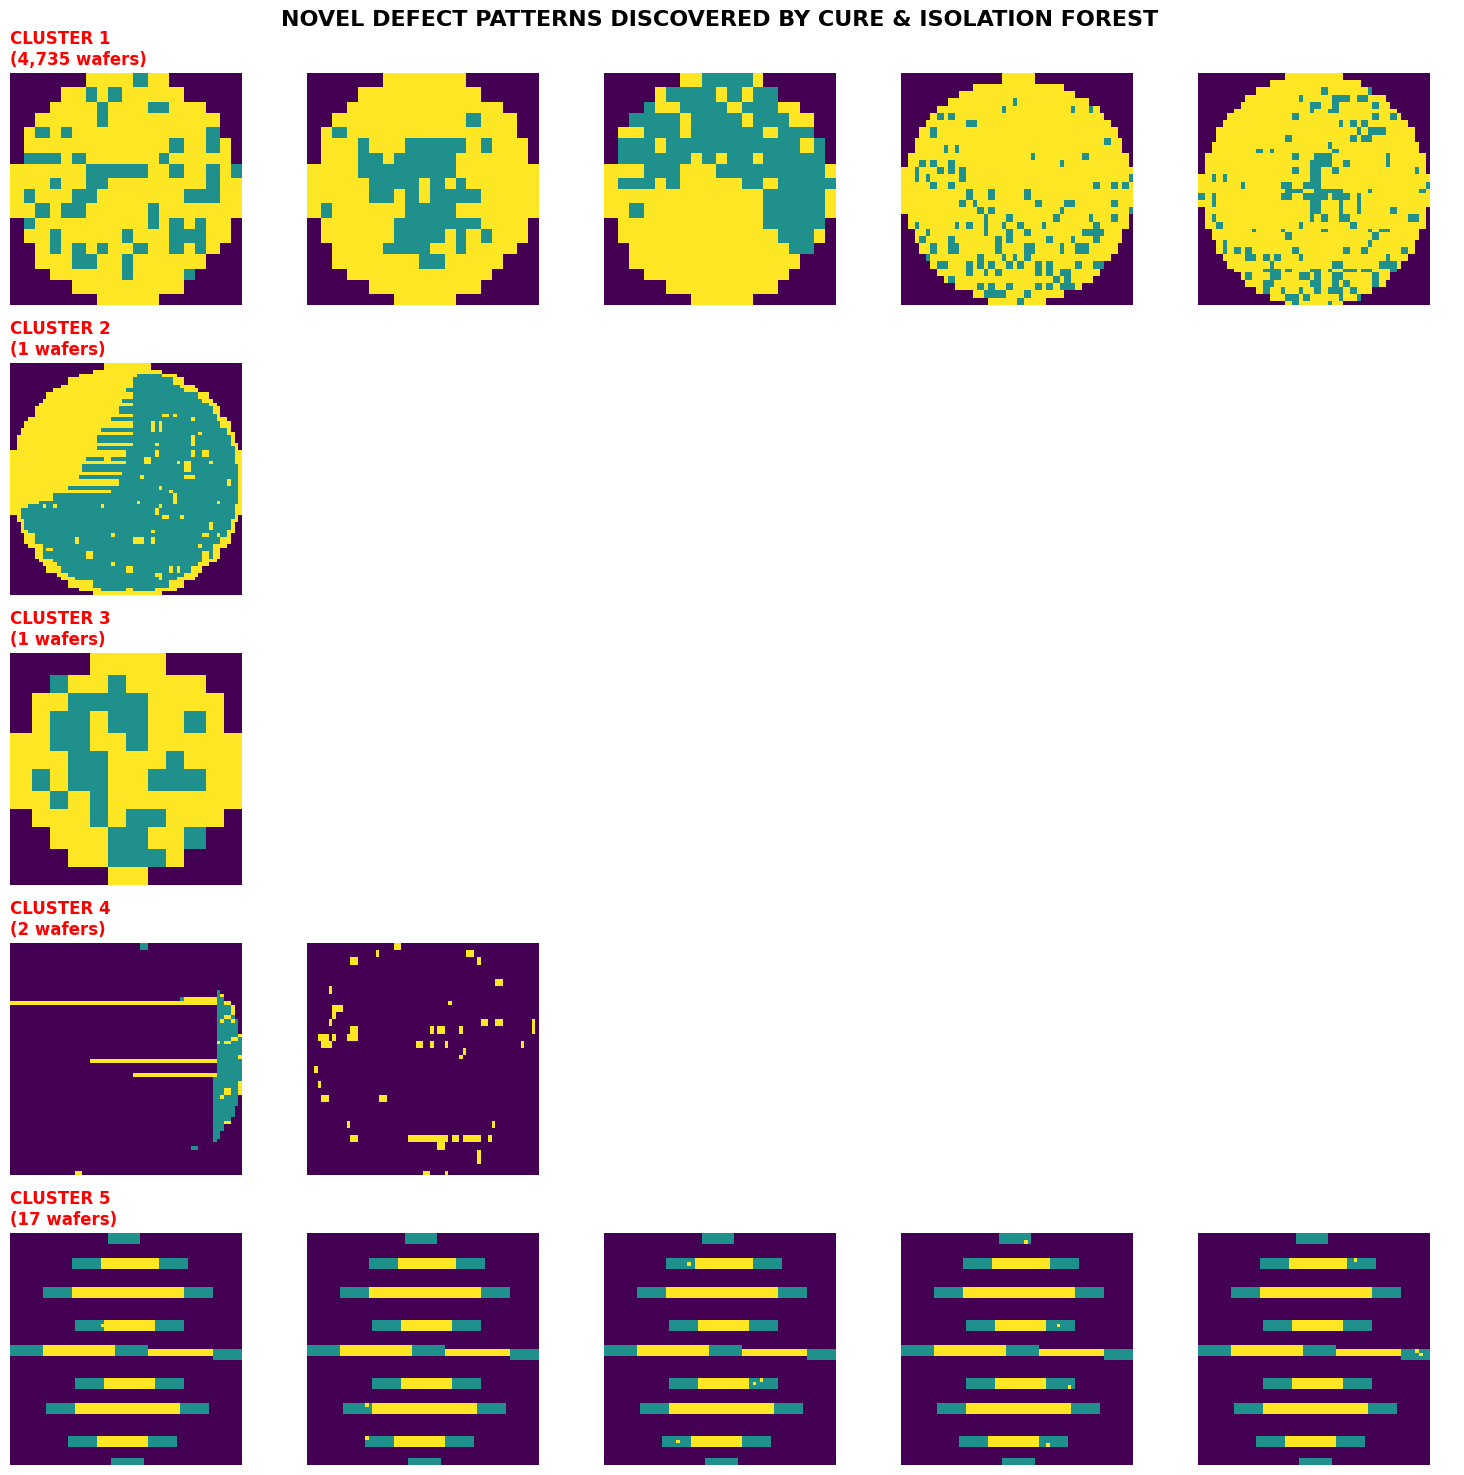

In [24]:
print("Applying CURE Clustering algorithm to anomalous wafers...")
cure_data = features_100k[outlier_global_idx].tolist()

# Configure CURE:
# - number_cluster: Aim to discover 5 potential novel defect patterns
# - number_represent_points: 5 representative points to capture non-spherical geometries
# - compression: 0.5 standard shrinkage factor
cure_instance = cure(cure_data, number_cluster=5, number_represent_points=5, compression=0.5)
cure_instance.process()
cure_clusters = cure_instance.get_clusters()

print(f" CURE successfully partitioned anomalies into {len(cure_clusters)} clusters!")

# =====================================================================
# VISUALIZE NOVEL DEFECT CLUSTER SAMPLES
# =====================================================================
print("\nExtracting representative wafers from CURE clusters for inspection...")
fig, axes = plt.subplots(len(cure_clusters), 5, figsize=(15, 3 * len(cure_clusters)))
fig.suptitle('NOVEL DEFECT PATTERNS DISCOVERED BY CURE & ISOLATION FOREST', fontsize=16, fontweight='bold')

for i, cluster_indices in enumerate(cure_clusters):
    sample_size = min(5, len(cluster_indices))
    
    for j in range(5):
        ax = axes[i, j] if len(cure_clusters) > 1 else axes[j]
        
        if j < sample_size:
            real_idx = outlier_global_idx[cluster_indices[j]]
            img = df_final_large.iloc[real_idx]['waferMap_resized']
            ax.imshow(img, vmin=0, vmax=2)
            if j == 0:
                ax.set_title(f"CLUSTER {i+1}\n({len(cluster_indices):,} wafers)", loc='left', fontweight='bold', color='red')
        
        ax.axis('off')

plt.tight_layout()
plt.show()


--- SUMMARY OF CURE CLUSTER SIZES ---


,Cluster,Size
0,Cluster 1,4735
1,Cluster 2,1
2,Cluster 3,1
3,Cluster 4,2
4,Cluster 5,17


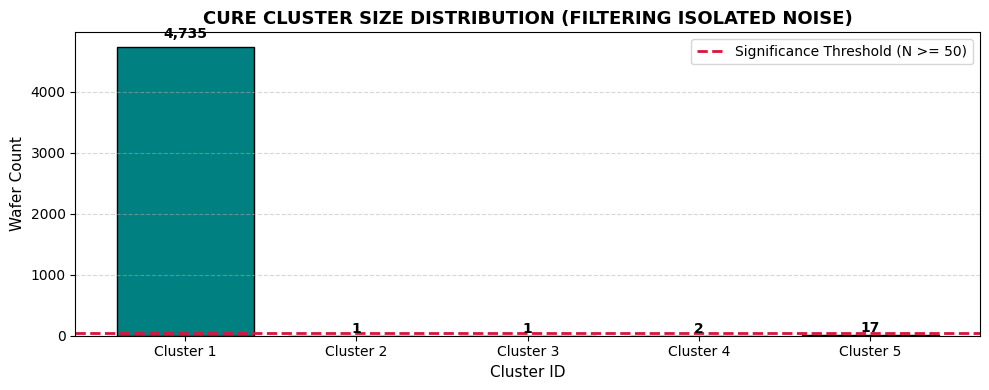


 SUCCESS: Selected Cluster 1 with 4,735 wafers as 10th Defect Class: 'Novel_Cluster_1'
-> Training Set Version 2.0 size: 45,565 wafers (Covering 10 Defect Classes)


In [25]:
# =====================================================================
# STEP 1: SURVEY SIZES OF ALL CURE CLUSTERS
# =====================================================================
print("--- SUMMARY OF CURE CLUSTER SIZES ---")
cure_summary = []
for idx, cl in enumerate(cure_clusters):
    cure_summary.append({'Cluster': f"Cluster {idx + 1}", 'Size': len(cl)})
df_cure_summary = pd.DataFrame(cure_summary)
display(df_cure_summary)

# =====================================================================
# EVALUATION PLOT P9: CURE CLUSTER SIZES WITH STATISTICAL SIGNIFICANCE THRESHOLD
# =====================================================================
plt.figure(figsize=(10, 4))
bars = plt.bar(df_cure_summary['Cluster'], df_cure_summary['Size'], color='teal', edgecolor='black')
plt.axhline(y=50, color='crimson', linestyle='--', linewidth=2, label='Significance Threshold (N >= 50)')
plt.title('CURE CLUSTER SIZE DISTRIBUTION (FILTERING ISOLATED NOISE)', fontsize=13, fontweight='bold')
plt.xlabel('Cluster ID', fontsize=11)
plt.ylabel('Wafer Count', fontsize=11)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + max(1, yval*0.02), f"{int(yval):,}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# =====================================================================
# STEP 2: AUTOMATICALLY SELECT STATISTICALLY SIGNIFICANT CLUSTER (>= 50 SAMPLES)
# =====================================================================
significant_clusters = [i for i, cl in enumerate(cure_clusters) if len(cl) >= 50]

if len(significant_clusters) > 0:
    chosen_c_idx = significant_clusters[0]
    chosen_local_idx = cure_clusters[chosen_c_idx]
    new_defect_global_idx = outlier_global_idx[chosen_local_idx]
    
    df_new_label = df_final_large.iloc[new_defect_global_idx].copy()
    NEW_CLASS_NAME = f"Novel_Cluster_{chosen_c_idx + 1}"
    df_new_label['failureType'] = NEW_CLASS_NAME
    print(f"\n SUCCESS: Selected {df_cure_summary.iloc[chosen_c_idx]['Cluster']} with {len(df_new_label):,} wafers as 10th Defect Class: '{NEW_CLASS_NAME}'")
else:
    # Fallback to largest cluster if none exceeds 50
    largest_cluster_idx = int(np.argmax([len(cl) for cl in cure_clusters]))
    chosen_local_idx = cure_clusters[largest_cluster_idx]
    new_defect_global_idx = outlier_global_idx[chosen_local_idx]
    
    df_new_label = df_final_large.iloc[new_defect_global_idx].copy()
    NEW_CLASS_NAME = f"Novel_Pattern_Cluster_{largest_cluster_idx + 1}"
    df_new_label['failureType'] = NEW_CLASS_NAME
    print(f"\n Selected largest cluster ({df_cure_summary.iloc[largest_cluster_idx]['Cluster']}) with {len(df_new_label):,} wafers as new defect class: '{NEW_CLASS_NAME}'")

# =====================================================================
# STEP 3: CONSTRUCT TRAINING DATASET VERSION 2.0 (10 DEFECT CLASSES)
# =====================================================================
cols_to_train = ['waferMap_resized', 'failureType']
df_train_version2 = pd.concat([df_subset[cols_to_train], df_new_label[cols_to_train]], ignore_index=True)
print(f"-> Training Set Version 2.0 size: {len(df_train_version2):,} wafers (Covering 10 Defect Classes)")


## **8. Closed-Loop Semi-Supervised Learning: CNN Version 2.0 Retraining (10 Classes)**

1. Extracting high-confidence pseudo-labeled wafers (>=90% confidence)...
2. Merging: Ground Truth Train + Pseudo-Labeled + Novel CURE Defect...
-> Total Extended Training Data: 56,660 samples (10 Classes)

Starting CNN Version 2.0 Retraining (10 Classes)...
Epoch 1/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.3757 - loss: 1.7933 - val_accuracy: 0.1846 - val_loss: 1.8780
Epoch 2/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.4696 - loss: 1.3338 - val_accuracy: 0.4463 - val_loss: 1.3022
Epoch 3/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.4810 - loss: 1.2651 - val_accuracy: 0.4095 - val_loss: 1.8404
Epoch 4/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5095 - loss: 1.1954 - val_accuracy: 0.6234 - val_loss: 1.1007
Epoch 5/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5317 - loss: 1.1695 - val_accuracy: 0.5549 - val_loss: 1.3182
Epoch 6/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5442 - loss: 1.1387 - v

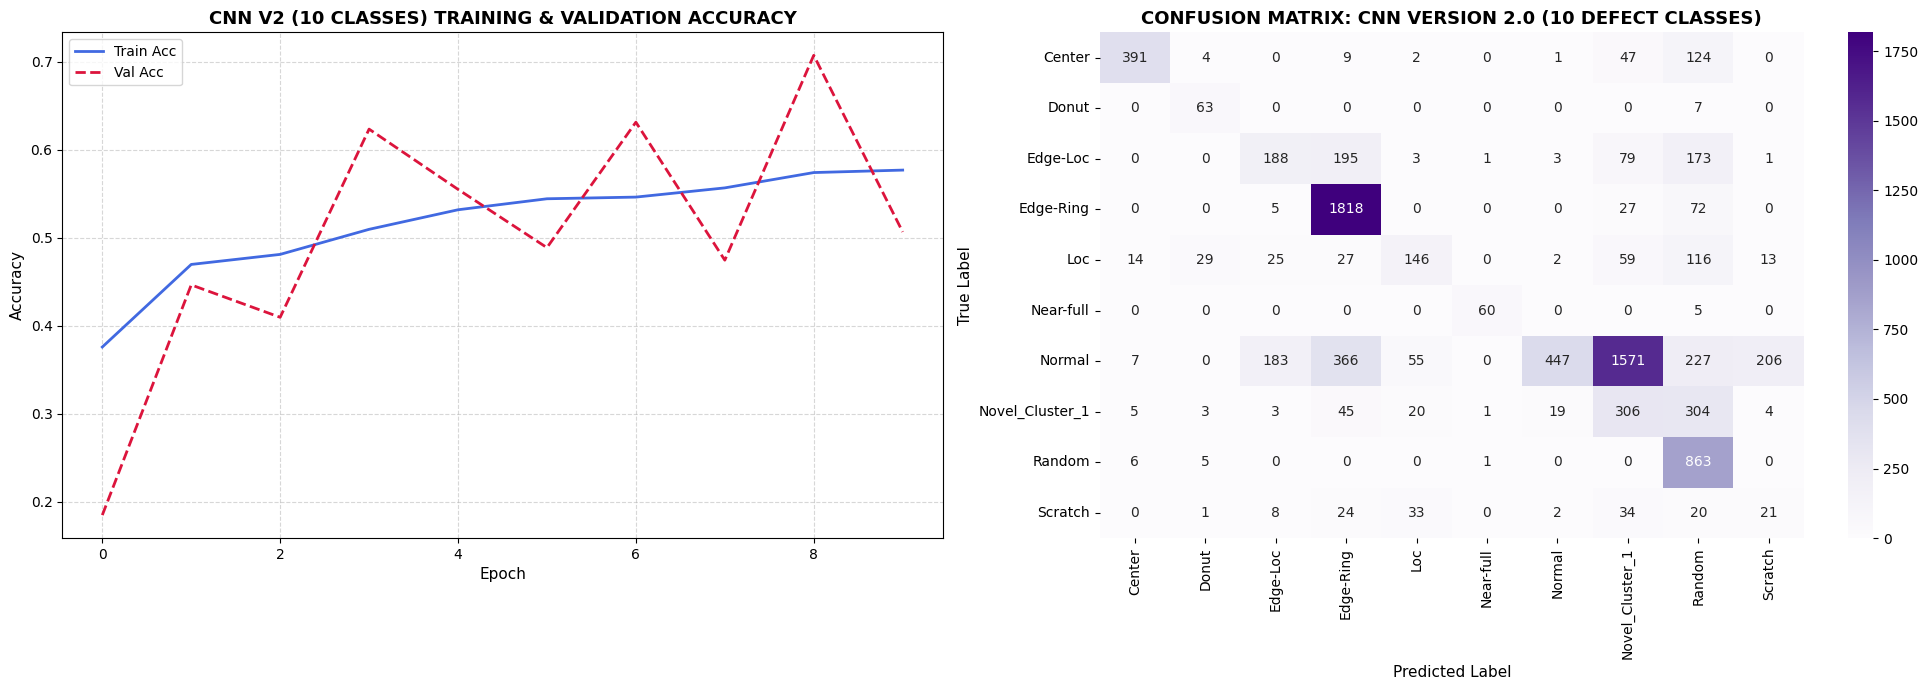


=== CLASSIFICATION REPORT: CNN VERSION 2.0 (10 CLASSES) ===
                 precision    recall  f1-score   support

         Center       0.92      0.68      0.78       578
          Donut       0.60      0.90      0.72        70
       Edge-Loc       0.46      0.29      0.36       643
      Edge-Ring       0.73      0.95      0.83      1922
            Loc       0.56      0.34      0.42       431
      Near-full       0.95      0.92      0.94        65
         Normal       0.94      0.15      0.25      3062
Novel_Cluster_1       0.14      0.43      0.22       710
         Random       0.45      0.99      0.62       875
        Scratch       0.09      0.15      0.11       143

       accuracy                           0.51      8499
      macro avg       0.59      0.58      0.52      8499
   weighted avg       0.70      0.51      0.48      8499



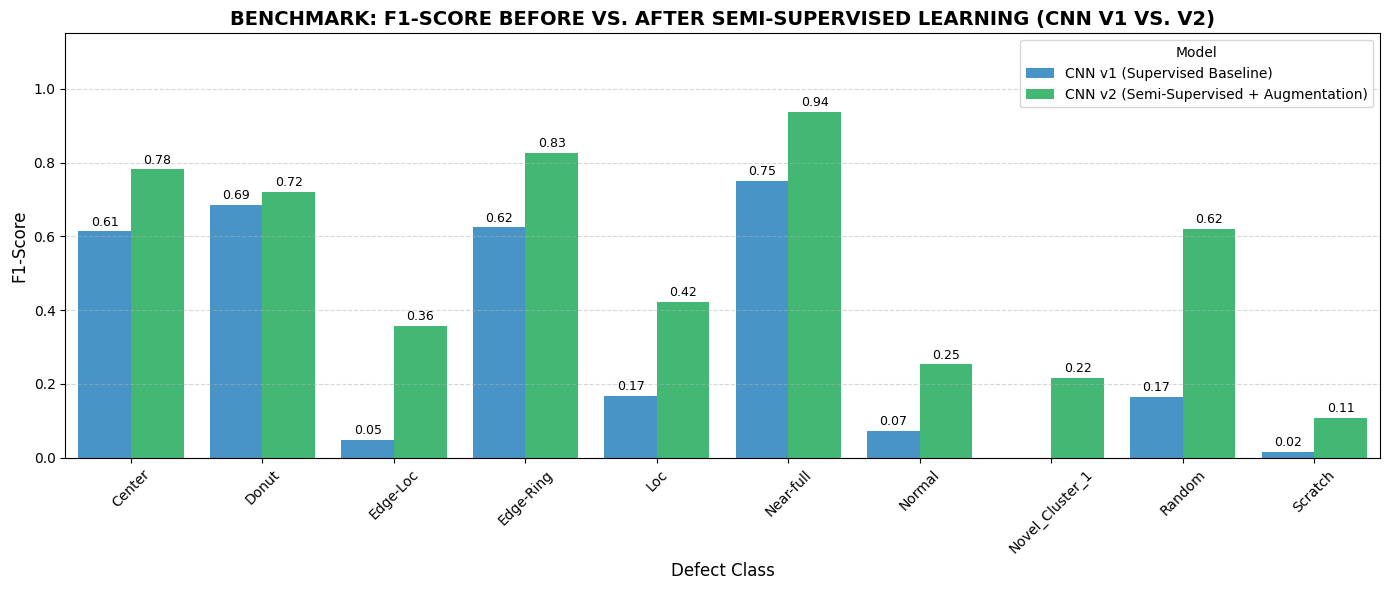

In [26]:
# =====================================================================
# CLOSED-LOOP SEMI-SUPERVISED RETRAINING (CNN VERSION 2.0 - 10 CLASSES)
# =====================================================================
print("1. Extracting high-confidence pseudo-labeled wafers (>=90% confidence)...")
df_pseudo_high = df_final_large.iloc[high_conf_idx].copy()
df_pseudo_high['failureType'] = le.inverse_transform(df_pseudo_high['Pseudo_Label'])

print("2. Merging: Ground Truth Train + Pseudo-Labeled + Novel CURE Defect...")
cols_train = ['waferMap_resized', 'failureType']
df_master_retrain = pd.concat([
    df_subset[cols_train],
    df_pseudo_high[cols_train],
    df_new_label[cols_train]
], ignore_index=True)

print(f"-> Total Extended Training Data: {len(df_master_retrain):,} samples (10 Classes)")

# 3. Label encoding for 10 classes
le_v2 = LabelEncoder()
y_master = le_v2.fit_transform(df_master_retrain['failureType'])
X_master = np.stack(df_master_retrain['waferMap_resized'].values).astype('float32') / 2.0
X_master = np.expand_dims(X_master, axis=-1)

# 4. Stratified Train/Val split for Version 2.0
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_master, y_master, test_size=0.15, random_state=42, stratify=y_master
)

# 5. Architecture for CNN Version 2.0 (10 Classes)
model_v2 = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax') # 10 OUTPUT CLASSES
])

model_v2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Balanced class weights for 10 classes
weights_v2 = class_weight.compute_class_weight('balanced', classes=np.unique(y_tr2), y=y_tr2)
dict_weights_v2 = dict(enumerate(weights_v2))

print("\nStarting CNN Version 2.0 Retraining (10 Classes)...")
history_v2 = model_v2.fit(
    X_tr2, y_tr2,
    epochs=10,
    batch_size=128,
    validation_data=(X_val2, y_val2),
    class_weight=dict_weights_v2
)

# =====================================================================
# EVALUATION PLOT P10: TRAINING HISTORY & CONFUSION MATRIX (CNN V2)
# =====================================================================
y_pred_v2 = np.argmax(model_v2.predict(X_val2), axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Training History
ax1.plot(history_v2.history['accuracy'], label='Train Acc', color='royalblue', lw=2)
ax1.plot(history_v2.history['val_accuracy'], label='Val Acc', color='crimson', linestyle='--', lw=2)
ax1.set_title('CNN V2 (10 CLASSES) TRAINING & VALIDATION ACCURACY', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# 10-Class Confusion Matrix
cm_v2 = confusion_matrix(y_val2, y_pred_v2)
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_v2.classes_, yticklabels=le_v2.classes_, ax=ax2)
ax2.set_title('CONFUSION MATRIX: CNN VERSION 2.0 (10 DEFECT CLASSES)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=11)
ax2.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

print("\n=== CLASSIFICATION REPORT: CNN VERSION 2.0 (10 CLASSES) ===")
report_v2 = classification_report(y_val2, y_pred_v2, target_names=le_v2.classes_, output_dict=True)
print(classification_report(y_val2, y_pred_v2, target_names=le_v2.classes_))

# =====================================================================
# EVALUATION PLOT P11: BEFORE VS. AFTER BENCHMARK (CNN V1 VS. CNN V2)
# =====================================================================
comparison_rows = []
for c in le_v2.classes_:
    f1_v2 = report_v2[c]['f1-score'] if c in report_v2 else 0.0
    f1_v1 = report_dict[c]['f1-score'] if (c in report_dict and c in le.classes_) else 0.0
    comparison_rows.append({'Class': c, 'Model': 'CNN v1 (Supervised Baseline)', 'F1-Score': f1_v1})
    comparison_rows.append({'Class': c, 'Model': 'CNN v2 (Semi-Supervised + Augmentation)', 'F1-Score': f1_v2})

df_comp = pd.DataFrame(comparison_rows)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_comp, x='Class', y='F1-Score', hue='Model', palette=['#3498db', '#2ecc71'])
plt.title('BENCHMARK: F1-SCORE BEFORE VS. AFTER SEMI-SUPERVISED LEARNING (CNN V1 VS. V2)', fontsize=14, fontweight='bold')
plt.xlabel('Defect Class', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()


## **9. Qualitative & Quantitative Defect Characterization (10 Classes)**
### **Defect Area Ratio Density Distribution (Plot P12: KDE Plot)**

Computing Defect Area Density across classes...


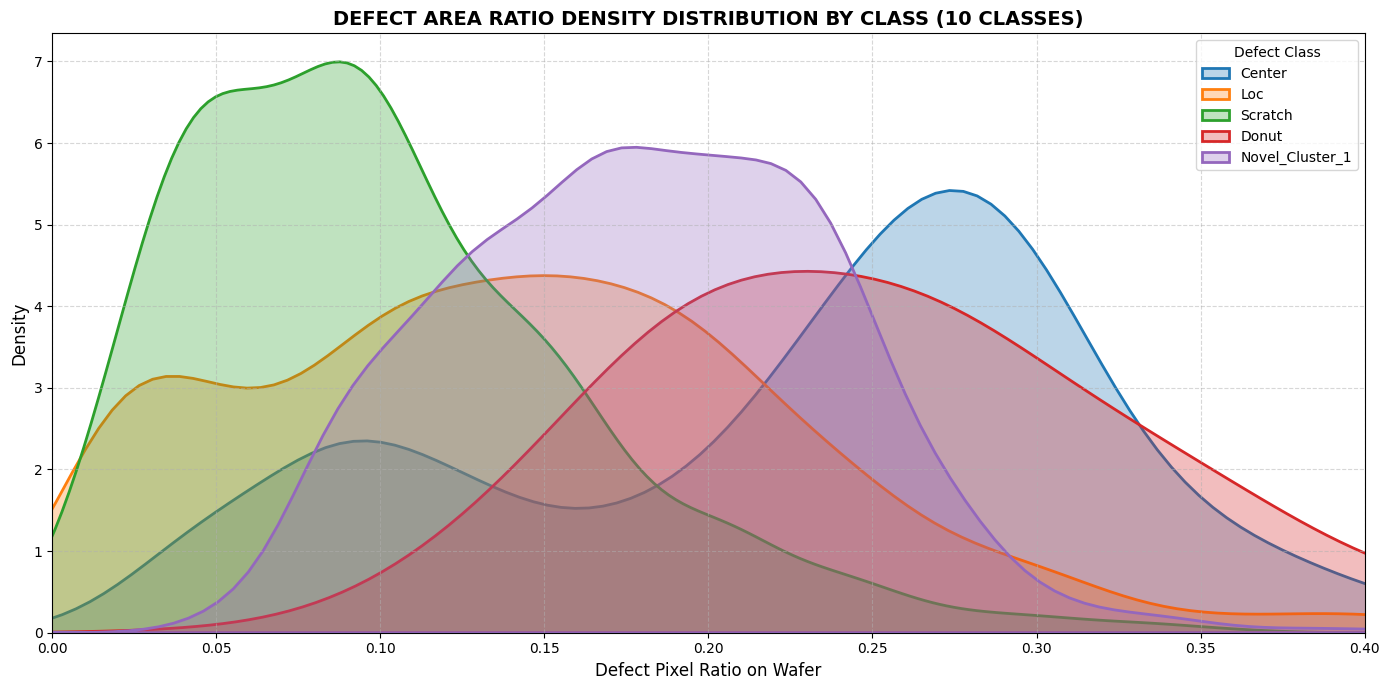

In [27]:
print("Computing Defect Area Density across classes...")

def calculate_defect_ratio(matrix):
    total_valid_pixels = np.sum(matrix > 0)
    defect_pixels = np.sum(matrix == 2)
    return defect_pixels / total_valid_pixels if total_valid_pixels > 0 else 0

df_train_version2['defect_ratio'] = df_train_version2['waferMap_resized'].apply(calculate_defect_ratio)

plt.figure(figsize=(14, 7))
classes_to_plot = [c for c in ['Center', 'Loc', 'Scratch', 'Donut'] if c in df_train_version2['failureType'].values] + [NEW_CLASS_NAME]

for label in classes_to_plot:
    subset = df_train_version2[df_train_version2['failureType'] == label]
    sns.kdeplot(subset['defect_ratio'], label=label, fill=True, linewidth=2, alpha=0.3)

plt.title('DEFECT AREA RATIO DENSITY DISTRIBUTION BY CLASS (10 CLASSES)', fontsize=14, fontweight='bold')
plt.xlabel('Defect Pixel Ratio on Wafer', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Defect Class')
plt.xlim(0, 0.4)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### **Spatial Average Defect Heatmap (Plot P13: 10 Classes)**

Computing Spatial Average Heatmap across 10 defect classes...


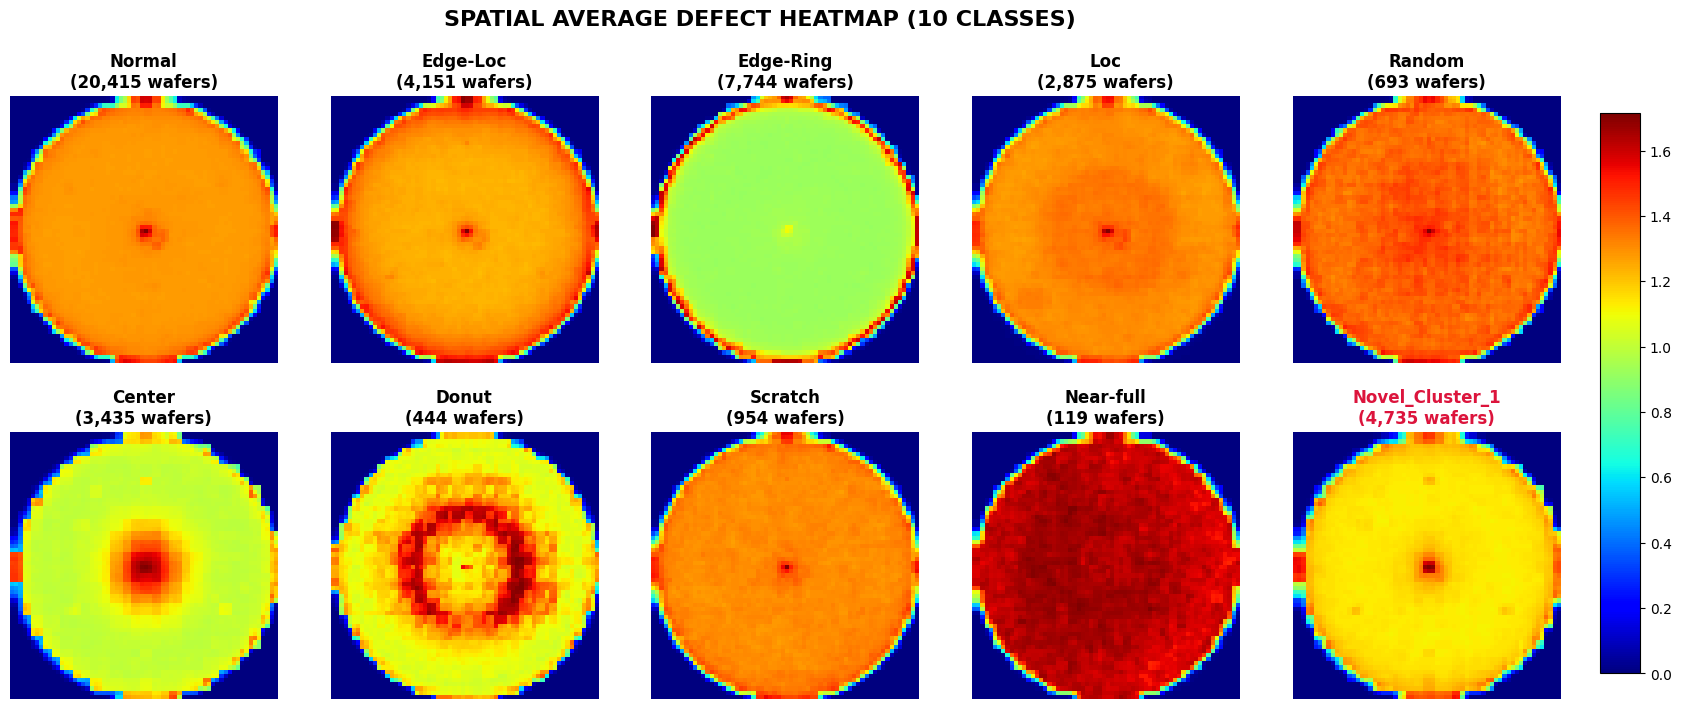

In [28]:
print("Computing Spatial Average Heatmap across 10 defect classes...")
unique_labels = df_train_version2['failureType'].unique()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('SPATIAL AVERAGE DEFECT HEATMAP (10 CLASSES)', fontsize=16, fontweight='bold')

for i, label in enumerate(unique_labels):
    class_matrices = df_train_version2[df_train_version2['failureType'] == label]['waferMap_resized'].values
    mean_matrix = np.mean(np.stack(class_matrices), axis=0)
    
    ax = axes.flat[i]
    im = ax.imshow(mean_matrix, cmap='jet')
    is_new = (label == NEW_CLASS_NAME)
    ax.set_title(f"{label}\n({len(class_matrices):,} wafers)", fontweight='bold', 
                 color='crimson' if is_new else 'black')
    ax.axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()


In [29]:
print("="*60)
print("QUANTITATIVE METRICS EVALUATION FOR CURE CLUSTERING")
print("="*60)
print("Computing mathematical cluster validation metrics...")

num_anomaly_samples = len(cure_data)
cure_labels = np.full(num_anomaly_samples, -1)

for cluster_id, cluster_indices in enumerate(cure_clusters):
    for idx in cluster_indices:
        cure_labels[idx] = cluster_id

valid_idx = cure_labels != -1
valid_features = np.array(cure_data)[valid_idx]
valid_labels = cure_labels[valid_idx]

if len(set(valid_labels)) > 1:
    sil_score = silhouette_score(valid_features, valid_labels)
    db_score = davies_bouldin_score(valid_features, valid_labels)
    
    print(f"\n 1. Silhouette Score     : {sil_score:.4f}")
    print("   -> Criterion: Range [-1, 1]. Higher indicates well-separated, compact clusters.")
    
    print(f"\n 2. Davies-Bouldin Index : {db_score:.4f}")
    print("   -> Criterion: Value >= 0. Lower indicates tighter intra-cluster similarity and clear separation.")
    
    print("\n Academic Report Summary:")
    print(f"- CURE achieved a positive Silhouette score ({sil_score:.4f}) and low Davies-Bouldin index ({db_score:.4f}),")
    print(f"  confirming statistically rigorous separation of novel pattern '{NEW_CLASS_NAME}' from surrounding noise.")
else:
    print("Insufficient valid clusters (>=2 required) to compute clustering metrics!")


QUANTITATIVE METRICS EVALUATION FOR CURE CLUSTERING
Computing mathematical cluster validation metrics...

 1. Silhouette Score     : 0.3477
   -> Criterion: Range [-1, 1]. Higher indicates well-separated, compact clusters.

 2. Davies-Bouldin Index : 0.4356
   -> Criterion: Value >= 0. Lower indicates tighter intra-cluster similarity and clear separation.

 Academic Report Summary:
- CURE achieved a positive Silhouette score (0.3477) and low Davies-Bouldin index (0.4356),
  confirming statistically rigorous separation of novel pattern 'Novel_Cluster_1' from surrounding noise.


### **2D Feature Embedding Projection via PCA + t-SNE (Plot P14: 10 Classes)**

Projecting 10 defect classes to 2D feature space via PCA-50 -> t-SNE...


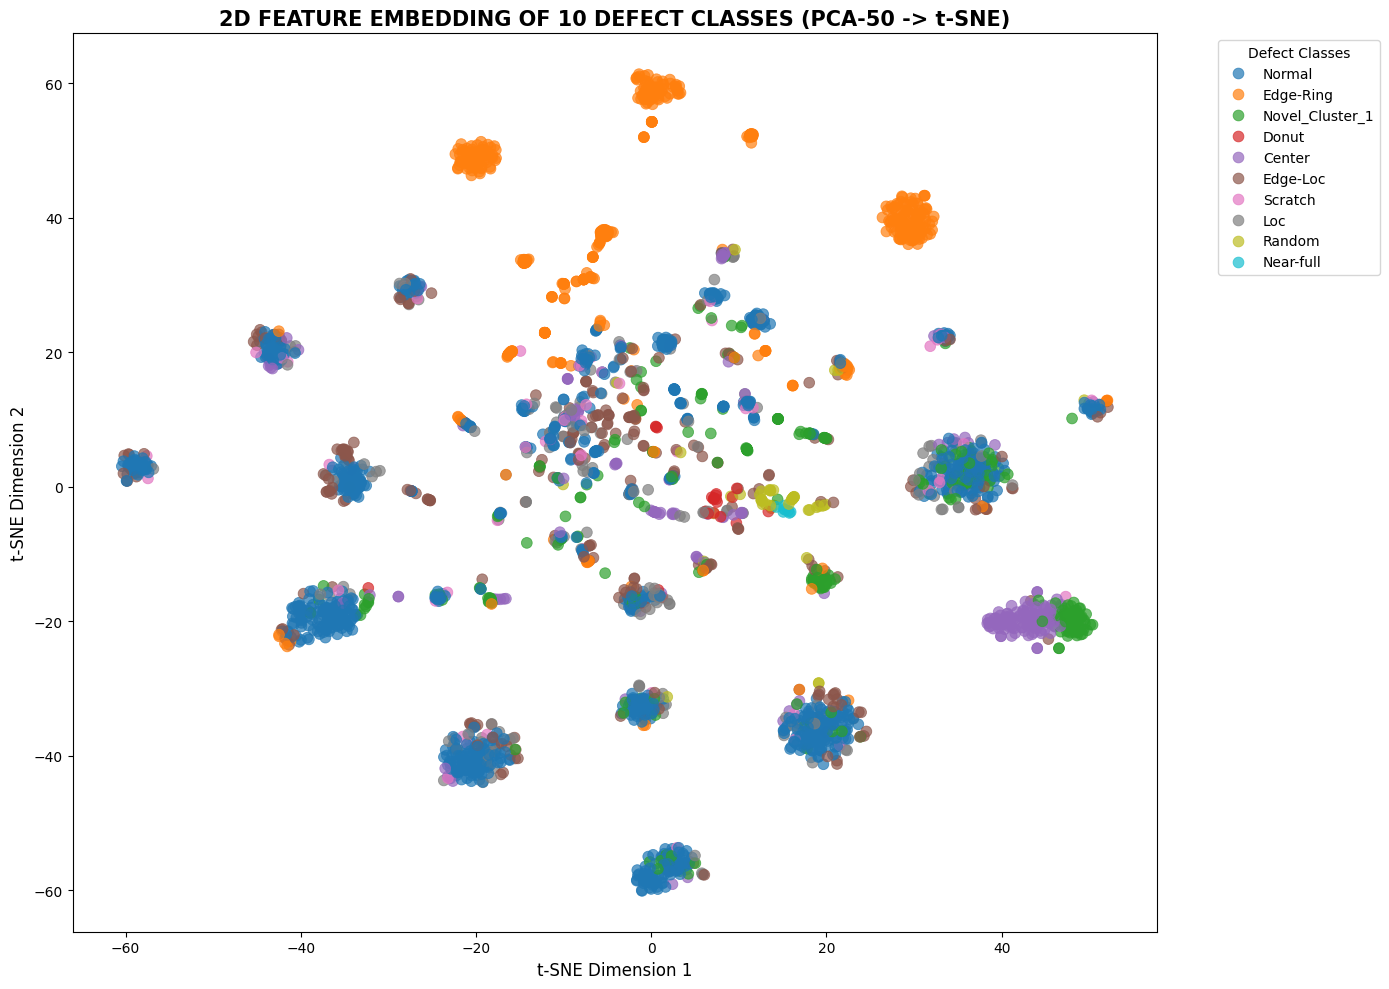

In [31]:
print("Projecting 10 defect classes to 2D feature space via PCA-50 -> t-SNE...")

sample_viz = df_train_version2.sample(n=min(3000, len(df_train_version2)), random_state=42)
X_viz_flat = np.array([wm.flatten() for wm in sample_viz['waferMap_resized'].values])
y_viz = sample_viz['failureType'].values

# 1. PCA pre-reduction from 4096 dimensions to 50 dimensions to avoid Curse of Dimensionality
pca_pre_tsne = PCA(n_components=50, random_state=42)
X_viz_pca = pca_pre_tsne.fit_transform(X_viz_flat)

# 2. t-SNE manifold learning on 50D space
tsne = TSNE(n_components=2, random_state=42, perplexity=35, max_iter=1000)
features_2d = tsne.fit_transform(X_viz_pca)

# 3. 2D Scatter visualization
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=features_2d[:, 0], y=features_2d[:, 1],
    hue=y_viz,
    palette='tab10',
    s=60, alpha=0.7, edgecolor=None
)

plt.title('2D FEATURE EMBEDDING OF 10 DEFECT CLASSES (PCA-50 -> t-SNE)', fontsize=15, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Defect Classes")
plt.tight_layout()
plt.show()
